In [35]:
import pandas as pd
from etl.load import get_engine
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from dotenv import load_dotenv

In [36]:
load_dotenv(r"c:\Users\admin\demand-forecasting\.env")

sys.path.append(r"c:\Users\admin\demand-forecasting")

In [37]:
import pandas as pd
from etl.load import get_engine

In [38]:
engine = get_engine()

In [39]:
query1 = """
    select categorie, count(item_id) as nbr_items
    from item
    group by categorie
"""

item_par_categorie = pd.read_sql(query1, engine)

item_par_categorie.head()

,categorie,nbr_items
0,HOBBIES,565
1,FOODS,1437
2,HOUSEHOLD,1047


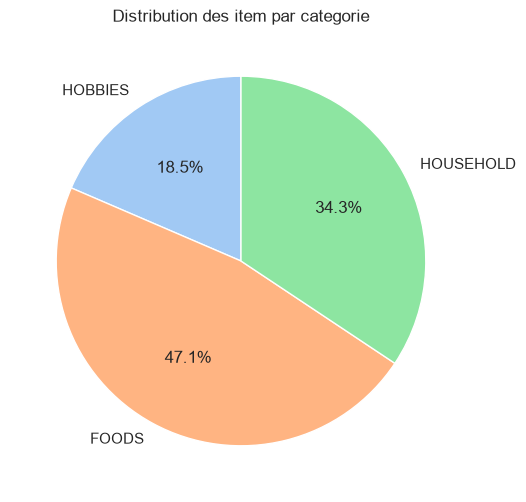

In [40]:
# Application du style Seaborn
sns.set_theme(style="whitegrid")

# Récupération d'une palette de couleurs Seaborn (ex: 'pastel', 'Set2', 'viridis')
couleurs = sns.color_palette('pastel')[0:len(item_par_categorie["nbr_items"])]

plt.figure(figsize=(6, 6))
plt.pie(
    item_par_categorie["nbr_items"], 
    labels=item_par_categorie["categorie"], 
    autopct='%1.1f%%', 
    colors=couleurs,
    startangle=90
)

plt.title('Distribution des item par categorie')
plt.show()

In [41]:
query2 = '''
    select etat, count(store_id)
    from store 
    group by etat
    '''

quantite_store_par_state = pd.read_sql(query2, engine)

quantite_store_par_state.tail()

,etat,count
0,WI,3
1,CA,4
2,TX,3


In [ ]:
# query3 = '''
#     select s.store_id, sum(quantite) as quantite_vendues, 
#     from fact_sales f join store s on f.store_id = s.id
#     group by s.store_id
#     order by quantite_vendues
#     '''

# quantite_vendues_par_state = pd.read_sql(query3, engine)

# quantite_vendues_par_state.head()

DatabaseError: Execution failed on sql '
    select s.store_id, sum(quantite) as quantite_vendues, 
    from fact_sales f join store s on f.store_id = s.id
    group by s.store_id
    order by quantite_vendues
    ': (psycopg2.errors.SyntaxError) syntax error at or near "from"
LINE 3:     from fact_sales f join store s on f.store_id = s.id
            ^

[SQL: 
    select s.store_id, sum(quantite) as quantite_vendues, 
    from fact_sales f join store s on f.store_id = s.id
    group by s.store_id
    order by quantite_vendues
    ]
(Background on this error at: https://sqlalche.me/e/20/f405)

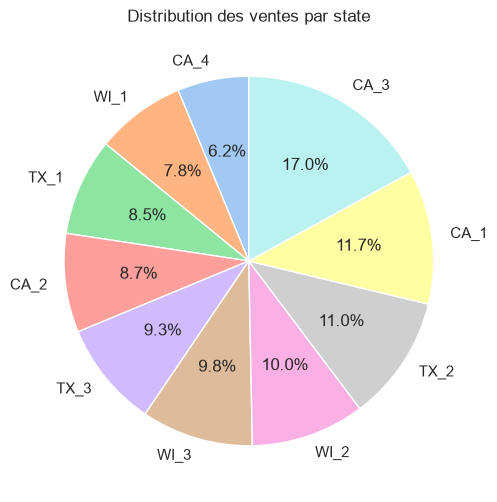

In [ ]:
# # Application du style Seaborn
# sns.set_theme(style="whitegrid")

# # Récupération d'une palette de couleurs Seaborn (ex: 'pastel', 'Set2', 'viridis')
# couleurs = sns.color_palette('pastel')[0:len(quantite_vendues_par_state["store_id"])]

# plt.figure(figsize=(6, 6))
# plt.pie(
#     quantite_vendues_par_state["quantite_vendues"], 
#     labels=quantite_vendues_par_state["store_id"], 
#     autopct='%1.1f%%', 
#     colors=couleurs,
#     startangle=90
# )

# plt.title('Distribution des ventes par state')
# plt.show()

In [44]:
query5 = '''
        SELECT quantite, COUNT(*) as freq
        FROM fact_sales
        GROUP BY quantite
        ORDER BY quantite
    '''

df_sales = pd.read_sql(query5, engine)

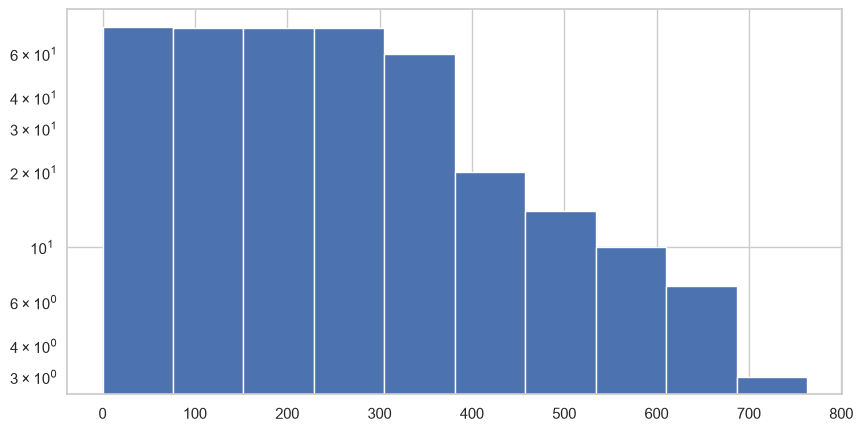

In [45]:
plt.figure(figsize=(10,5))
df_sales["quantite"].hist()
plt.yscale("log")
plt.show()